<a href="https://colab.research.google.com/github/RiabtsevaAnne/lab/blob/main/%22%D0%9B%D0%A04_%D0%9C%D0%9D_%D0%A0%D1%8F%D0%B1%D1%86%D0%B5%D0%B2%D0%B0_4_9_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №4. Регресійні моделі: глибоке дослідження

**Датасет:** Car Price Prediction Multiple Linear Regression  
https://www.kaggle.com/datasets/hellbuoy/car-price-prediction?select=CarPrice_Assignment.csv

**Мета роботи:** виконати підготовку даних, побудувати та порівняти регресійні моделі для прогнозування ціни автомобіля, оцінити їх якість і проаналізувати отримані результати.

> У шаблоні наведено лише умови завдань. Реалізацію необхідно виконати самостійно у порожніх комірках.


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hellbuoy/car-price-prediction")

print("Path to dataset files:", path)

100%|██████████| 18.1k/18.1k [00:00<00:00, 21.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/hellbuoy/car-price-prediction/versions/1


## 1. Завантаження та первинний аналіз даних

Завантажити датасет та виконати його первинний огляд:
- визначити кількість об'єктів і ознак;
- переглянути назви стовпців;
- визначити типи даних;
- визначити цільову змінну;
- вивести основні статистичні характеристики даних.


In [5]:
import pandas as pd
import os
print(os.listdir(path))

['Data Dictionary - carprices.xlsx', 'CarPrice_Assignment.csv']


In [7]:
df = pd.read_csv(os.path.join(path, "CarPrice_Assignment.csv"))
display(df.head())

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [9]:
print("Розмір датасету:", df.shape)

Розмір датасету: (205, 26)


In [11]:
print(df.columns.tolist())

['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']


In [12]:
print(df.dtypes)

car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object


In [13]:
target = "price"
print("Цільова змінна:", target)

Цільова змінна: price


In [14]:
display(df.describe())

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## 2. Перевірка якості даних

Перевірити:
- наявність пропущених значень;
- наявність повних дублікатів;
- кількість унікальних значень в ознаках.

Під час аналізу врахувати, що `car_ID` є унікальним ідентифікатором автомобіля і сам по собі не повинен використовуватися для визначення дублікатів за змістовими характеристиками.


In [15]:
print("Кількість пропущених значень у кожному стовпці:")
print(df.isnull().sum())

Кількість пропущених значень у кожному стовпці:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


In [16]:
df_without_id = df.drop(columns=["car_ID"])
duplicates = df_without_id.duplicated().sum()
print("\nКількість повних дублікатів без урахування car_ID:", duplicates)


Кількість повних дублікатів без урахування car_ID: 0


In [17]:
print("\nКількість унікальних значень у кожному стовпці:")
print(df.nunique())



Кількість унікальних значень у кожному стовпці:
car_ID              205
symboling             6
CarName             147
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight            49
curbweight          171
enginetype            7
cylindernumber        7
enginesize           44
fuelsystem            8
boreratio            38
stroke               37
compressionratio     32
horsepower           59
peakrpm              23
citympg              29
highwaympg           30
price               189
dtype: int64


In [18]:
unique_values = pd.DataFrame({
    "Стовпець": df.columns,
    "Кількість унікальних значень": [df[col].nunique() for col in df.columns]
})
display(unique_values)

,Стовпець,Кількість унікальних значень
0,car_ID,205
1,symboling,6
2,CarName,147
3,fueltype,2
4,aspiration,2
5,doornumber,2
6,carbody,5
7,drivewheel,3
8,enginelocation,2
9,wheelbase,53


## 3. Робота з car_ID

Зберегти `car_ID` окремо для подальшої ідентифікації автомобілів у результатах прогнозування.  
Не використовувати `car_ID` як ознаку під час навчання моделей.


In [19]:
car_ids = df["car_ID"].copy()
df_model = df.drop(columns=["car_ID"])
print("Збережені car_ID:")
display(car_ids.head())
print("\nСтовпці, які будуть використовуватися для моделювання:")
print(df_model.columns.tolist())

Збережені car_ID:


,car_ID
0,1
1,2
2,3
3,4
4,5



Стовпці, які будуть використовуватися для моделювання:
['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']


## 4. Дослідження розподілів числових ознак

Дослідити розподіли числових ознак:
- побудувати відповідні графіки;
- обчислити коефіцієнти асиметрії;
- визначити ознаки з найбільш вираженою асиметрією;
- коротко прокоментувати отримані результати.


In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
numeric_features.remove("car_ID")

print("Числові ознаки:")
print(numeric_features)

Числові ознаки:
['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']


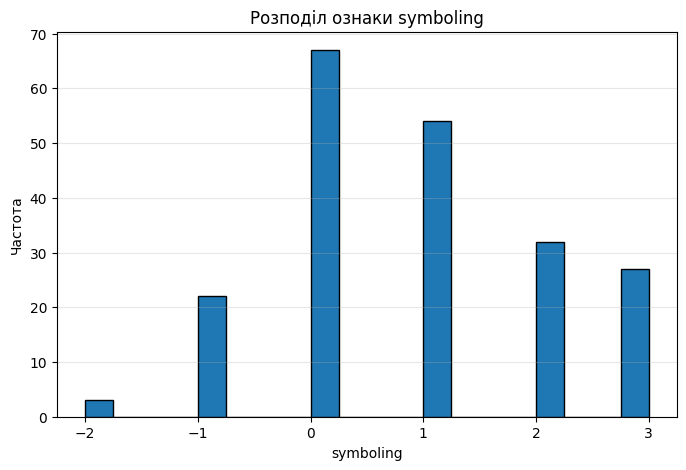

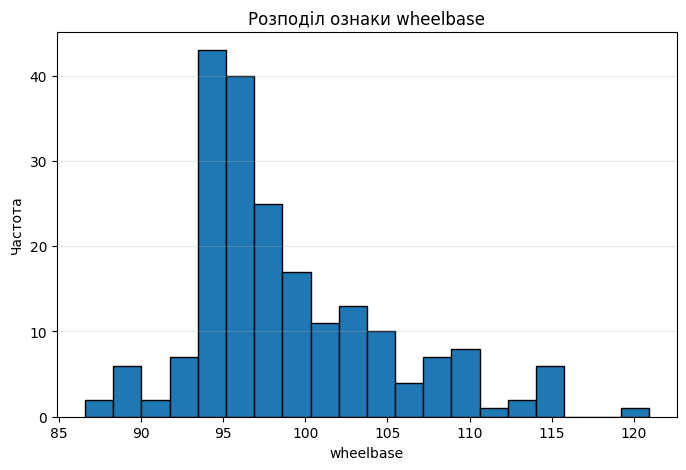

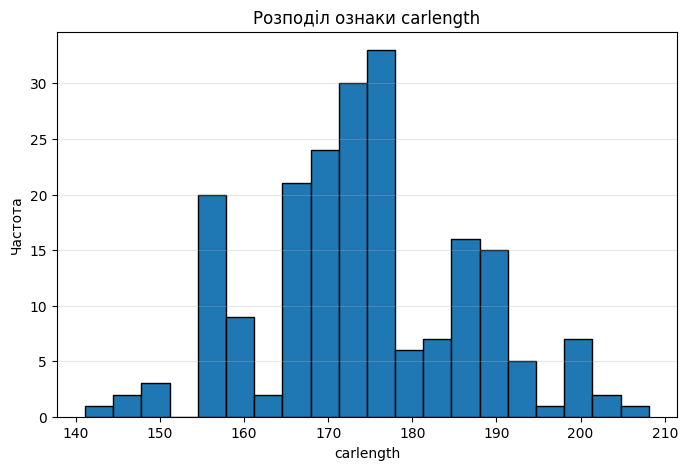

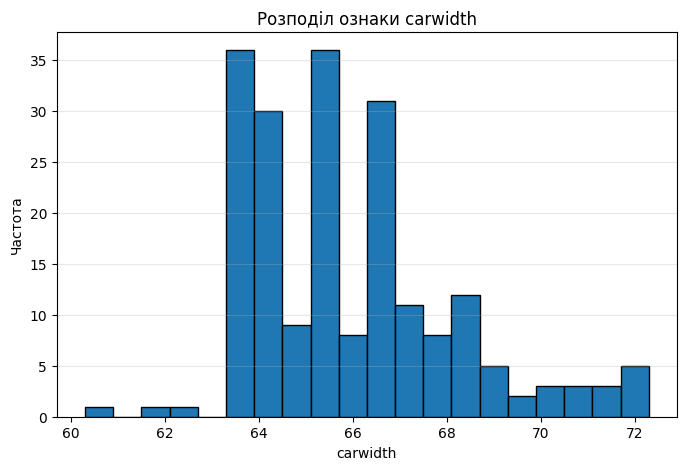

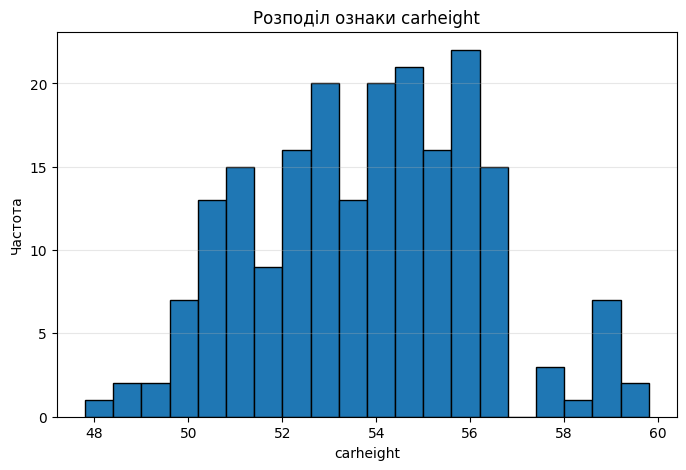

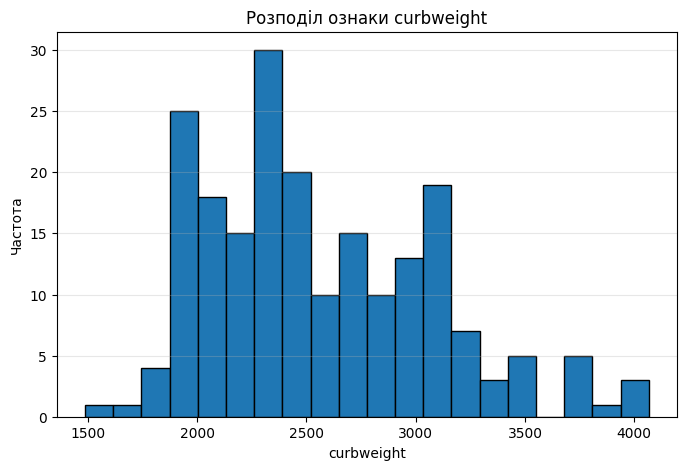

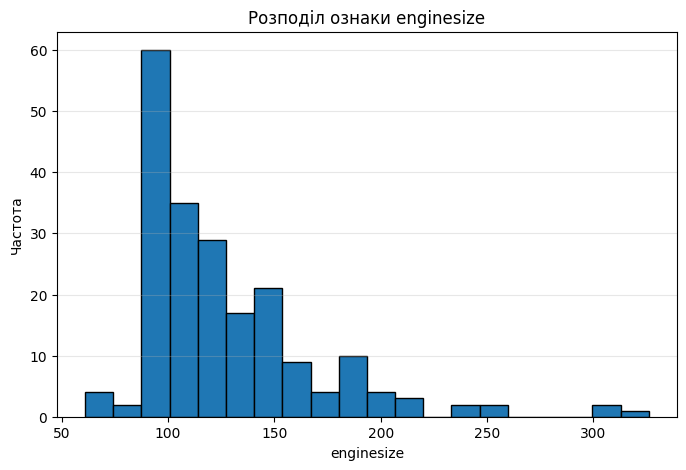

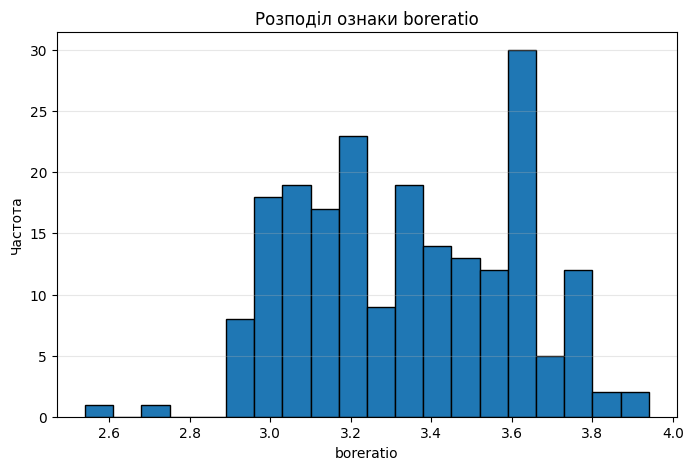

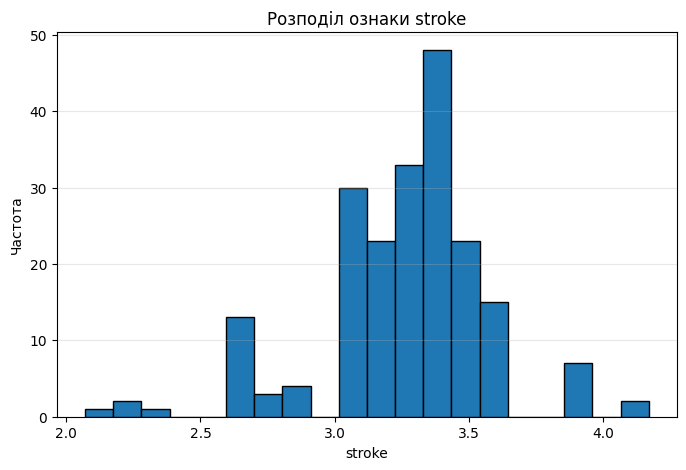

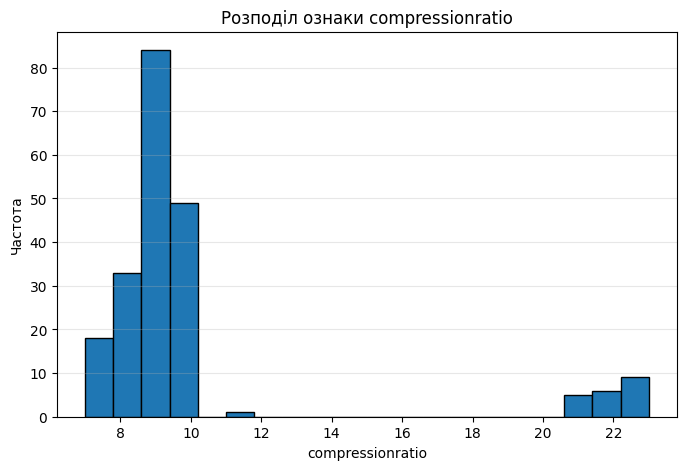

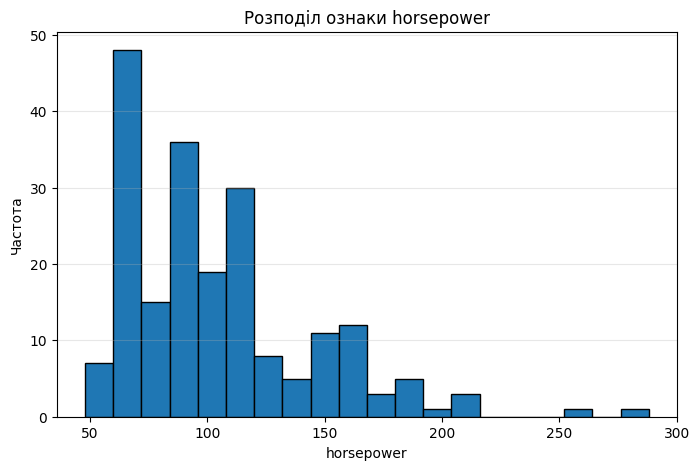

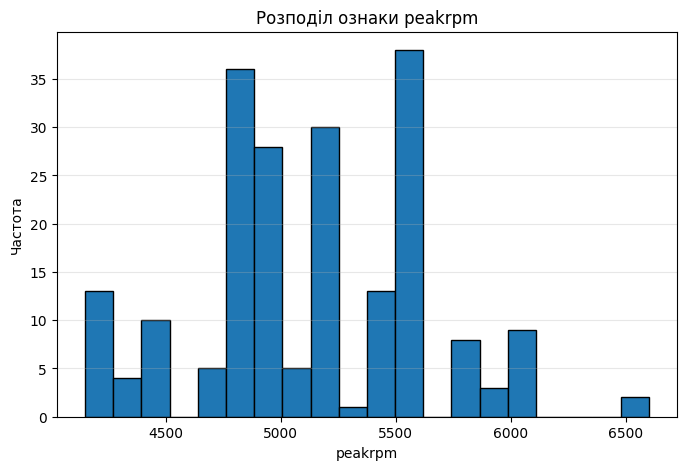

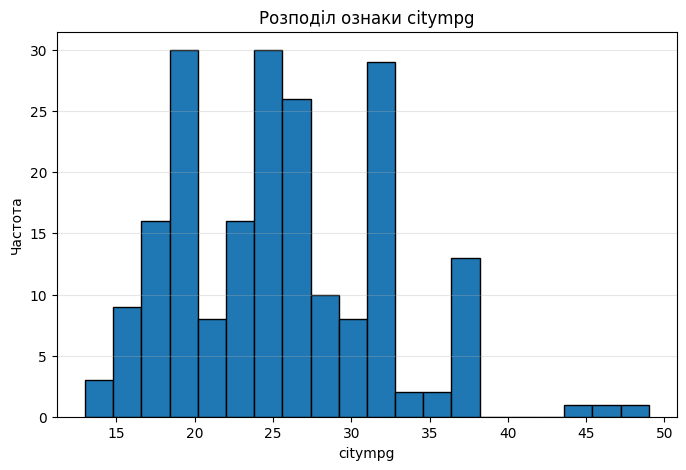

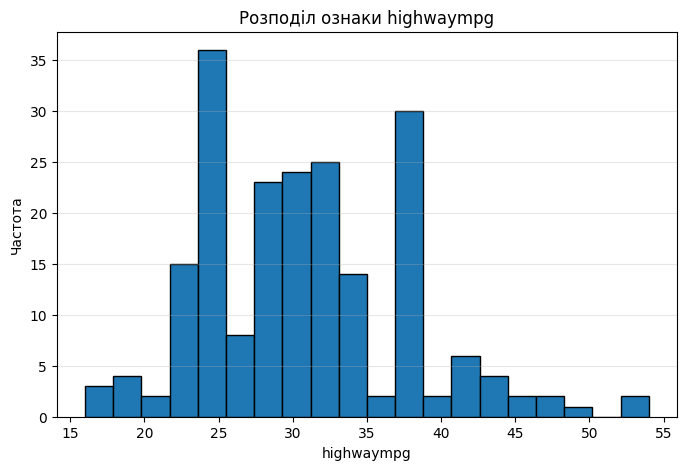

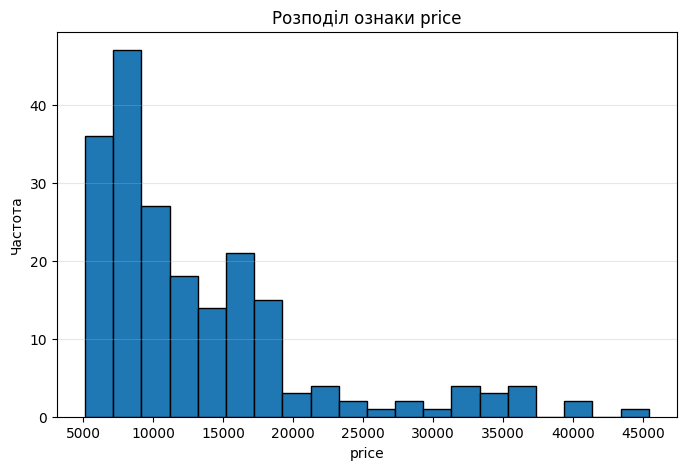

In [21]:
for column in numeric_features:
    plt.figure(figsize=(8, 5))

    plt.hist(df[column], bins=20, edgecolor="black")

    plt.title(f"Розподіл ознаки {column}")
    plt.xlabel(column)
    plt.ylabel("Частота")
    plt.grid(axis="y", alpha=0.3)

    plt.show()

In [22]:
skewness = df[numeric_features].skew()
print(skewness.sort_values(ascending=False))

compressionratio    2.610862
enginesize          1.947655
price               1.777678
horsepower          1.405310
wheelbase           1.050214
carwidth            0.904003
curbweight          0.681398
citympg             0.663704
highwaympg          0.539997
symboling           0.211072
carlength           0.155954
peakrpm             0.075159
carheight           0.063123
boreratio           0.020156
stroke             -0.689705
dtype: float64


## 5. Формування train/test вибірок

Відокремити цільову змінну `price` від ознак та розділити дані на:
- навчальну вибірку — 80%;
- тестову вибірку — 20%.

Забезпечити відтворюваність поділу.  
Окремо зберегти `car_ID` для об'єктів, які потрапили до train і test.

**Важливо:** усі подальші параметри передобробки даних визначати тільки за навчальною вибіркою.


In [23]:
most_skewed = skewness.abs().sort_values(ascending=False)
print(most_skewed)

compressionratio    2.610862
enginesize          1.947655
price               1.777678
horsepower          1.405310
wheelbase           1.050214
carwidth            0.904003
stroke              0.689705
curbweight          0.681398
citympg             0.663704
highwaympg          0.539997
symboling           0.211072
carlength           0.155954
peakrpm             0.075159
carheight           0.063123
boreratio           0.020156
dtype: float64


## 6. Аналіз та обробка викидів

Для неперервних числових ознак навчальної вибірки:
- визначити потенційні викиди методом IQR;
- вивести кількість потенційних викидів для кожної ознаки;
- обґрунтувати спосіб їх обробки.

Для невеликого набору даних не видаляти автоматично всі рядки з викидами. Використати обмеження крайніх значень межами, визначеними за навчальною вибіркою.

Цільову змінну `price` не використовувати для визначення меж викидів.  
До тестової вибірки застосувати ті самі межі, які були отримані за train.


In [24]:
X = df_model.drop(columns=["price"])
y = df_model["price"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()
print("Неперервні числові ознаки:")
print(numeric_features)

Неперервні числові ознаки:
['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']


In [25]:
iqr_limits = pd.DataFrame(columns=["Ознака", "Q1", "Q3", "IQR", "Нижня межа", "Верхня межа"])
outlier_counts = {}
for column in numeric_features:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (
        (X_train[column] < lower_bound) |
        (X_train[column] > upper_bound)
    )

    outlier_counts[column] = outliers.sum()

    iqr_limits.loc[len(iqr_limits)] = [
        column,
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound
    ]

print("Межі IQR для навчальної вибірки:")
display(iqr_limits)

Межі IQR для навчальної вибірки:


,Ознака,Q1,Q3,IQR,Нижня межа,Верхня межа
0,symboling,0.000,2.000,2.000,-3.0000,5.0000
1,wheelbase,94.500,102.100,7.600,83.1000,113.5000
2,carlength,166.675,183.200,16.525,141.8875,207.9875
3,carwidth,64.175,66.675,2.500,60.4250,70.4250
4,carheight,51.900,55.525,3.625,46.4625,60.9625
5,curbweight,2163.000,2939.250,776.250,998.6250,4103.6250
6,enginesize,98.000,141.000,43.000,33.5000,205.5000
7,boreratio,3.150,3.540,0.390,2.5650,4.1250
8,stroke,3.110,3.410,0.300,2.6600,3.8600
9,compressionratio,8.600,9.400,0.800,7.4000,10.6000


In [26]:
outlier_table = pd.DataFrame({
    "Ознака": outlier_counts.keys(),
    "Кількість потенційних викидів": outlier_counts.values()
})

display(outlier_table)

,Ознака,Кількість потенційних викидів
0,symboling,0
1,wheelbase,6
2,carlength,0
3,carwidth,10
4,carheight,0
5,curbweight,0
6,enginesize,7
7,boreratio,1
8,stroke,16
9,compressionratio,20


In [27]:
X_train_capped = X_train.copy()
X_test_capped = X_test.copy()
for column in numeric_features:
    lower_bound = iqr_limits.loc[
        iqr_limits["Ознака"] == column,
        "Нижня межа"
    ].iloc[0]
    upper_bound = iqr_limits.loc[
        iqr_limits["Ознака"] == column,
        "Верхня межа"
    ].iloc[0]
    X_train_capped[column] = X_train_capped[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )
    X_test_capped[column] = X_test_capped[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

## 7. Аналіз кореляцій та відбір ознак

За навчальною вибіркою:
- побудувати матрицю кореляцій числових ознак;
- знайти пари ознак із сильною кореляцією, для яких `|r| > 0.85`;
- для кожної такої пари залишити одну ознаку;
- під час вибору врахувати силу зв'язку кожної ознаки з цільовою змінною `price`;
- вивести список сильно корельованих пар та перелік ознак, які видаляються.

Із тестової вибірки видалити ті самі ознаки.  
Не використовувати тестову вибірку для прийняття рішення про відбір ознак.


In [28]:
train_corr_data = X_train_capped[numeric_features].copy()
train_corr_data["price"] = y_train
corr_matrix = train_corr_data.corr()

print("Матриця кореляцій:")
display(corr_matrix)

Матриця кореляцій:


,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
symboling,1.000000,-0.529886,-0.335504,-0.188751,-0.537134,-0.184052,-0.019755,-0.069261,-0.050779,-0.062137,0.129422,0.282002,-0.109415,-0.029365,-0.005183
wheelbase,-0.529886,1.000000,0.867043,0.776252,0.583080,0.744827,0.480384,0.436310,0.191481,0.002648,0.334326,-0.377828,-0.410237,-0.494257,0.504036
carlength,-0.335504,0.867043,1.000000,0.838946,0.464789,0.865988,0.655872,0.558943,0.141090,-0.054099,0.556342,-0.320005,-0.630014,-0.670892,0.652071
carwidth,-0.188751,0.776252,0.838946,1.000000,0.240133,0.858047,0.708562,0.541332,0.170756,-0.049741,0.626537,-0.226593,-0.632576,-0.666401,0.731623
carheight,-0.537134,0.583080,0.464789,0.240133,1.000000,0.246243,0.015726,0.130297,-0.011801,0.087016,-0.124711,-0.318205,0.003616,-0.062927,0.044458
curbweight,-0.184052,0.744827,0.865988,0.858047,0.246243,1.000000,0.848682,0.626735,0.123413,-0.093797,0.756743,-0.280823,-0.752704,-0.796620,0.824212
enginesize,-0.019755,0.480384,0.655872,0.708562,0.015726,0.848682,1.000000,0.613366,0.161773,-0.088349,0.830252,-0.247532,-0.684215,-0.687571,0.845969
boreratio,-0.069261,0.436310,0.558943,0.541332,0.130297,0.626735,0.613366,1.000000,-0.111057,-0.081739,0.558497,-0.273495,-0.564362,-0.563640,0.547119
stroke,-0.050779,0.191481,0.141090,0.170756,-0.011801,0.123413,0.161773,-0.111057,1.000000,-0.058567,0.054362,-0.042811,-0.003004,-0.000669,-0.006416
compressionratio,-0.062137,0.002648,-0.054099,-0.049741,0.087016,-0.093797,-0.088349,-0.081739,-0.058567,1.000000,-0.318740,-0.158121,0.461834,0.425007,-0.060275


In [29]:
strong_pairs = []
features_for_corr = numeric_features
for i in range(len(features_for_corr)):
    for j in range(i + 1, len(features_for_corr)):

        feature_1 = features_for_corr[i]
        feature_2 = features_for_corr[j]

        r = corr_matrix.loc[feature_1, feature_2]

        if abs(r) > 0.85:
            strong_pairs.append({
                "Ознака 1": feature_1,
                "Ознака 2": feature_2,
                "Кореляція": r
            })
strong_pairs_df = pd.DataFrame(strong_pairs)

print("Пари ознак із сильною кореляцією |r| > 0.85:")
if len(strong_pairs_df) > 0:
    display(strong_pairs_df)
else:
    print("Сильно корельованих пар не знайдено.")

Пари ознак із сильною кореляцією |r| > 0.85:


,Ознака 1,Ознака 2,Кореляція
0,wheelbase,carlength,0.867043
1,carlength,curbweight,0.865988
2,carwidth,curbweight,0.858047
3,citympg,highwaympg,0.963620


In [31]:
price_correlations = corr_matrix["price"].drop("price")
print("Кореляція ознак із price:")
display(
    price_correlations
    .abs()
    .sort_values(ascending=False)
)

Кореляція ознак із price:


,price
enginesize,0.845969
curbweight,0.824212
horsepower,0.807101
carwidth,0.731623
highwaympg,0.716460
citympg,0.711245
carlength,0.652071
boreratio,0.547119
wheelbase,0.504036
peakrpm,0.069658


In [32]:
price_correlations = corr_matrix["price"].drop("price")
print("Кореляція ознак із price:")
display(
    price_correlations
    .abs()
    .sort_values(ascending=False)
)

Кореляція ознак із price:


,price
enginesize,0.845969
curbweight,0.824212
horsepower,0.807101
carwidth,0.731623
highwaympg,0.716460
citympg,0.711245
carlength,0.652071
boreratio,0.547119
wheelbase,0.504036
peakrpm,0.069658


In [35]:
X_train_selected = X_train_capped.drop(
    columns=features_to_remove
)
X_test_selected = X_test_capped.drop(
    columns=features_to_remove
)
print("Розмір X_train до відбору:", X_train_capped.shape)
print("Розмір X_train після відбору:", X_train_selected.shape)

print("\nРозмір X_test до відбору:", X_test_capped.shape)
print("Розмір X_test після відбору:", X_test_selected.shape)

Розмір X_train до відбору: (164, 24)
Розмір X_train після відбору: (164, 20)

Розмір X_test до відбору: (41, 24)
Розмір X_test після відбору: (41, 20)


In [34]:
features_to_remove = set()

selection_results = []

for pair in strong_pairs:
    feature_1 = pair["Ознака 1"]
    feature_2 = pair["Ознака 2"]
    pair_corr = pair["Кореляція"]

    corr_price_1 = abs(price_correlations[feature_1])
    corr_price_2 = abs(price_correlations[feature_2])

    if corr_price_1 >= corr_price_2:
        keep = feature_1
        remove = feature_2
    else:
        keep = feature_2
        remove = feature_1

    features_to_remove.add(remove)

    selection_results.append({
        "Ознака 1": feature_1,
        "Ознака 2": feature_2,
        "Кореляція між ознаками": pair_corr,
        f"|corr({feature_1}, price)|": corr_price_1,
        f"|corr({feature_2}, price)|": corr_price_2,
        "Залишаємо": keep,
        "Видаляємо": remove
    })
selection_df = pd.DataFrame(selection_results)
print("Рішення щодо сильно корельованих пар:")
display(selection_df)

Рішення щодо сильно корельованих пар:


,Ознака 1,Ознака 2,Кореляція між ознаками,"|corr(wheelbase, price)|","|corr(carlength, price)|",Залишаємо,Видаляємо,"|corr(curbweight, price)|","|corr(carwidth, price)|","|corr(citympg, price)|","|corr(highwaympg, price)|"
0,wheelbase,carlength,0.867043,0.504036,0.652071,carlength,wheelbase,NaN,NaN,NaN,NaN
1,carlength,curbweight,0.865988,NaN,0.652071,curbweight,carlength,0.824212,NaN,NaN,NaN
2,carwidth,curbweight,0.858047,NaN,NaN,curbweight,carwidth,0.824212,0.731623,NaN,NaN
3,citympg,highwaympg,0.963620,NaN,NaN,highwaympg,citympg,NaN,NaN,0.711245,0.71646


In [37]:
print("Ознаки після відбору:")
print(X_train_selected.columns.tolist())

Ознаки після відбору:
['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'highwaympg']


## 8. Підготовка числових і категоріальних ознак

Розділити ознаки на:
- неперервні числові;
- дискретну числову ознаку `symboling`;
- категоріальні.

Для неперервних числових ознак виконати послідовно:
1. перетворення Yeo–Johnson для зменшення асиметрії;
2. масштабування за допомогою StandardScaler.

Для `symboling` виконати масштабування без Yeo–Johnson.

Категоріальні ознаки закодувати методом One-Hot Encoding. Передбачити коректну обробку категорій у test, яких не було у train.

Усі перетворення об'єднати в єдиний механізм передобробки даних, який навчається тільки на `X_train`.


In [39]:
discrete_features = ["symboling"]

continuous_features = X_train_selected.select_dtypes(
    include=np.number
).columns.tolist()
continuous_features = [
    col for col in continuous_features
    if col != "symboling"
]
categorical_features = X_train_selected.select_dtypes(
    exclude=np.number
).columns.tolist()
print(continuous_features)
print(discrete_features)
print(categorical_features)

['carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'highwaympg']
['symboling']
['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


## 9. Перевірка трансформації числових ознак

Перевірити результат трансформації неперервних числових ознак:
- застосувати до train ту саму послідовність перетворень, яка буде використана в моделях;
- повторно обчислити коефіцієнти асиметрії;
- порівняти їх із початковими значеннями;
- зробити короткий висновок щодо ефективності трансформації.


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler

continuous_pipeline = Pipeline([
    ("yeo_johnson", PowerTransformer(
        method="yeo-johnson",
        standardize=False
    )),
    ("scaler", StandardScaler())
])

In [45]:
discrete_features = ["symboling"]
continuous_features = X_train_selected.select_dtypes(
    include=np.number
).columns.tolist()
continuous_features = [
    col for col in continuous_features
    if col != "symboling"
]
categorical_features = X_train_selected.select_dtypes(
    exclude=np.number
).columns.tolist()
print(continuous_features)
print(discrete_features)
print(categorical_features)

['carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'highwaympg']
['symboling']
['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


In [48]:
from sklearn.preprocessing import (
    PowerTransformer,
    StandardScaler,
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer

In [49]:
continuous_pipeline = Pipeline([
    (
        "yeo_johnson",
        PowerTransformer(
            method="yeo-johnson",
            standardize=False
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [50]:
symboling_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    )
])

In [51]:
categorical_pipeline = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            continuous_pipeline,
            continuous_features
        ),
        (
            "symboling",
            symboling_pipeline,
            discrete_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [53]:
X_train_prepared = preprocessor.fit_transform(
    X_train_selected
)
X_test_prepared = preprocessor.transform(
    X_test_selected
)

In [54]:
feature_names = preprocessor.get_feature_names_out()



In [55]:
X_train_prepared_df = pd.DataFrame(
    X_train_prepared,
    columns=feature_names,
    index=X_train_selected.index
)

X_test_prepared_df = pd.DataFrame(
    X_test_prepared,
    columns=feature_names,
    index=X_test_selected.index
)

In [56]:
print("Розмір X_train до передобробки:",
      X_train_selected.shape)

print("Розмір X_test до передобробки:",
      X_test_selected.shape)

print("\nРозмір X_train після передобробки:",
      X_train_prepared.shape)

print("Розмір X_test після передобробки:",
      X_test_prepared.shape)
print("\nКількість отриманих ознак:",
      len(feature_names))

print("\nПерші 5 рядків підготовленого X_train:")
display(X_train_prepared_df.head())

Розмір X_train до передобробки: (164, 20)
Розмір X_test до передобробки: (41, 20)

Розмір X_train після передобробки: (164, 171)
Розмір X_test після передобробки: (41, 171)

Кількість отриманих ознак: 171

Перші 5 рядків підготовленого X_train:


,continuous__carheight,continuous__curbweight,continuous__enginesize,continuous__boreratio,continuous__stroke,continuous__compressionratio,continuous__horsepower,continuous__peakrpm,continuous__highwaympg,symboling__symboling,...,categorical__cylindernumber_twelve,categorical__cylindernumber_two,categorical__fuelsystem_1bbl,categorical__fuelsystem_2bbl,categorical__fuelsystem_4bbl,categorical__fuelsystem_idi,categorical__fuelsystem_mfi,categorical__fuelsystem_mpfi,categorical__fuelsystem_spdi,categorical__fuelsystem_spfi
66,0.283461,0.455778,0.540306,0.419807,1.470292,1.998322,-0.962378,-1.944939,1.291931,-0.727380,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
111,1.203945,1.063079,0.101671,0.529800,-2.022836,-0.845060,0.010873,-0.285652,-1.034713,-0.727380,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
153,2.151912,-0.439830,-1.147848,-1.009773,-0.884725,-0.057773,-1.559900,-0.696264,1.011557,-0.727380,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
96,0.323736,-1.320157,-0.875082,-0.626791,0.042883,0.461933,-1.126949,0.122373,1.011557,0.078636,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
38,-0.161118,-0.417480,-0.275707,-0.626791,1.210481,-0.057773,-0.319702,1.332027,0.426961,-0.727380,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 10. Побудова регресійних моделей

Побудувати та навчити такі моделі:
- Linear Regression;
- Ridge Regression;
- Lasso Regression;
- Random Forest Regressor;
- Gradient Boosting Regressor;
- Support Vector Regressor (SVR).

Для кожної моделі створити єдиний Pipeline, який містить:
1. попередню обробку ознак;
2. відповідну регресійну модель.

Використати однакову схему підготовки даних для коректного порівняння моделей.


In [57]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR


In [59]:
linear_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

ridge_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", Ridge())
])
lasso_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", Lasso())
])

random_forest_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42
    ))
])
gradient_boosting_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])
svr_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", SVR())
])


In [60]:
models = {
    "Linear Regression": linear_pipeline,
    "Ridge Regression": ridge_pipeline,
    "Lasso Regression": lasso_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline,
    "SVR": svr_pipeline
}
for name, model in models.items():
    model.fit(X_train_selected, y_train)
    print(f"{name} — навчено")

Linear Regression — навчено
Ridge Regression — навчено
Lasso Regression — навчено
Random Forest — навчено
Gradient Boosting — навчено
SVR — навчено


## 11. Оцінювання якості моделей

Для кожної моделі:
- виконати навчання на тренувальній вибірці;
- отримати прогноз для тестової вибірки;
- обчислити метрики **R², MAE, MSE та MAPE**.

`MAPE` подати у відсотках.

Результати всіх моделей об'єднати в одну порівняльну таблицю та впорядкувати за значенням R² від найбільшого до найменшого.

Під час інтерпретації врахувати:
- R² — чим більше, тим краще;
- MAE, MSE, MAPE — чим менше, тим краще.


In [61]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [66]:
results = []

for name, model in models.items():
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(
        y_test,
        y_pred
    ) * 100
    results.append({
        "Модель": name,
        "R²": r2,
        "MAE": mae,
        "MSE": mse,
        "MAPE (%)": mape
    })


In [67]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        "R²": "{:.4f}",
        "MAE": "{:.2f}",
        "MSE": "{:.2f}",
        "MAPE (%)": "{:.2f}%"
    })
)

,Модель,R²,MAE,MSE,MAPE (%)
0,Random Forest,0.9494,1447.34,3996761.37,10.36%
1,Gradient Boosting,0.9291,1703.69,5596688.22,12.64%
2,Ridge Regression,0.7957,2712.77,16129423.33,23.07%
3,Lasso Regression,0.7061,3088.99,23202797.20,22.61%
4,Linear Regression,0.5481,4078.23,35676914.46,29.97%
5,SVR,-0.0997,5696.45,86811600.83,36.02%


## 12. Пояснення вибору типу моделі

Пояснити, чому класифікаційна модель, наприклад Logistic Regression, не підходить для безпосереднього прогнозування неперервної ціни автомобіля.

Зазначити, до якого типу задачі належить прогнозування `price` та чому моделі, використані в роботі, відповідають цій задачі.


## 13. Візуальне порівняння прогнозів

Для кожної побудованої моделі зобразити співвідношення:
- фактичних значень `price`;
- прогнозованих значень `price`.

Додати лінію ідеального прогнозу та проаналізувати, наскільки близько до неї розташовані прогнозовані значення. Звернути увагу на великі відхилення.


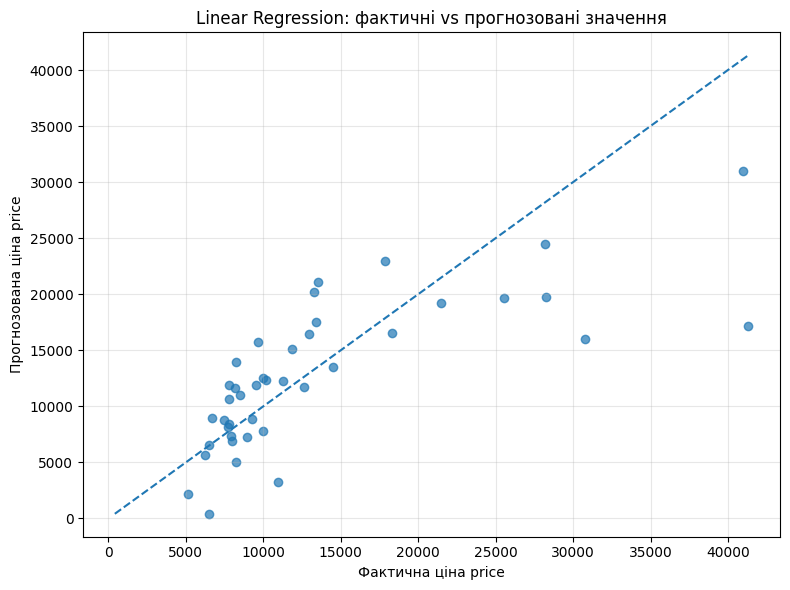

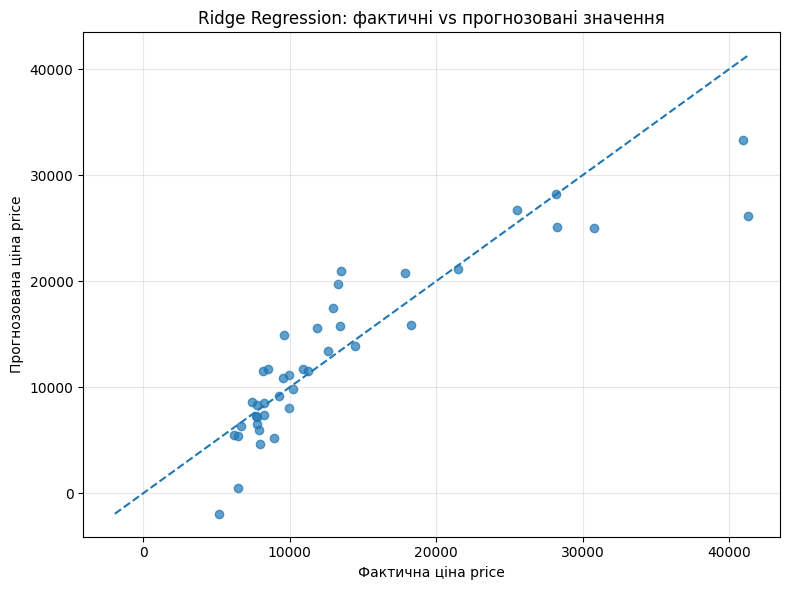

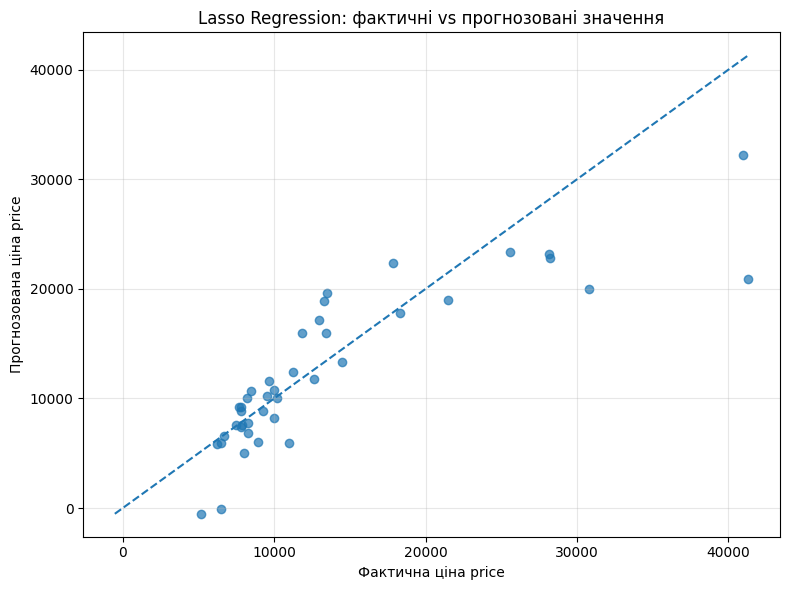

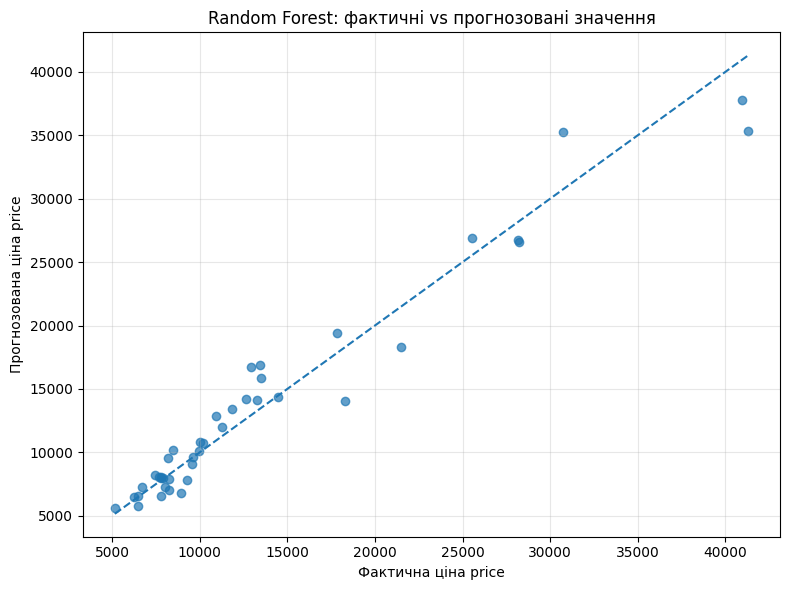

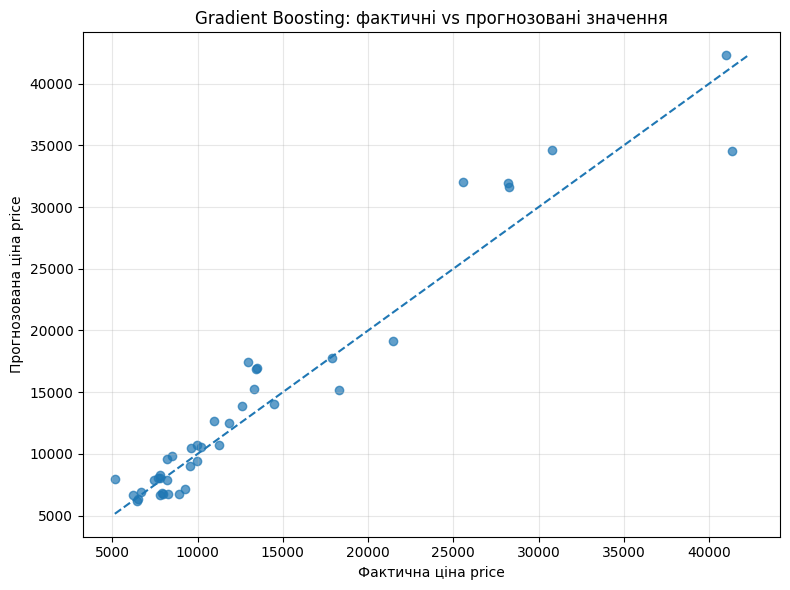

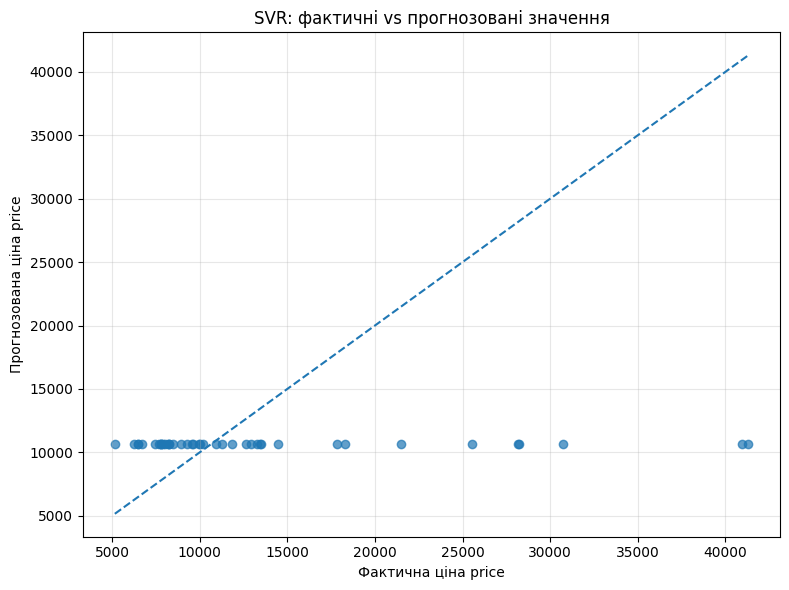

In [68]:
for name, model in models.items():
    y_pred = model.predict(X_test_selected)
    min_value = min(y_test.min(), y_pred.min())
    max_value = max(y_test.max(), y_pred.max())
    plt.figure(figsize=(8, 6))
    plt.scatter(
        y_test,
        y_pred,
        alpha=0.7
    )
    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )
    plt.xlabel("Фактична ціна price")
    plt.ylabel("Прогнозована ціна price")
    plt.title(f"{name}: фактичні vs прогнозовані значення")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 14. Прогноз для 10 автомобілів

Випадково вибрати 10 автомобілів із тестової вибірки.

За допомогою моделі Random Forest отримати для них прогноз ціни та сформувати таблицю з такими даними:
- `car_ID`;
- фактична ціна;
- прогнозована ціна;
- абсолютна помилка;
- абсолютна відсоткова помилка.

Прокоментувати отримані результати.


In [69]:
rf_model = models["Random Forest"]
rf_model.fit(X_train_selected, y_train)
random_indices = X_test_selected.sample(
    n=10,
    random_state=42
).index
X_test_10 = X_test_selected.loc[random_indices]
y_test_10 = y_test.loc[random_indices]
car_ids_10 = car_ids.loc[random_indices]
y_pred_10 = rf_model.predict(X_test_10)
prediction_table = pd.DataFrame({
    "car_ID": car_ids_10.values,
    "Фактична ціна": y_test_10.values,
    "Прогнозована ціна": y_pred_10
})
prediction_table["Абсолютна помилка"] = (
    prediction_table["Фактична ціна"] -
    prediction_table["Прогнозована ціна"]
).abs()
prediction_table["Абсолютна відсоткова помилка (%)"] = (
    prediction_table["Абсолютна помилка"] /
    prediction_table["Фактична ціна"] * 100
)

prediction_table["Прогнозована ціна"] = prediction_table[
    "Прогнозована ціна"
].round(2)

prediction_table["Абсолютна помилка"] = prediction_table[
    "Абсолютна помилка"
].round(2)

prediction_table["Абсолютна відсоткова помилка (%)"] = prediction_table[
    "Абсолютна відсоткова помилка (%)"
].round(2)
display(prediction_table)

,car_ID,Фактична ціна,Прогнозована ціна,Абсолютна помилка,Абсолютна відсоткова помилка (%)
0,26,6692.0,7298.80,606.81,9.07
1,176,9988.0,10798.65,810.65,8.12
2,148,10198.0,10714.57,516.57,5.07
3,17,41315.0,35310.69,6004.31,14.53
4,69,28248.0,26595.28,1652.72,5.85
5,147,7463.0,8230.00,767.00,10.28
6,144,9960.0,10065.20,105.20,1.06
7,85,14489.0,14346.48,142.52,0.98
8,195,12940.0,16765.65,3825.65,29.56
9,160,7788.0,7995.56,207.56,2.67


## 15. Висновки

Сформулювати підсумкові висновки за результатами роботи.

У висновках:
- порівняти якість усіх моделей;
- проаналізувати R², MAE, MSE і MAPE;
- зазначити, яка модель показала найкращі результати за отриманими метриками;
- прокоментувати величину похибок;
- звернути увагу на можливі ознаки перенавчання;
- коротко оцінити вплив попередньої обробки даних на результати моделювання.


## Загальні вимоги до виконання

- Не використовувати тестову вибірку для визначення меж викидів, кореляційного відбору ознак, навчання трансформерів, масштабування або кодування категорій.
- Усі параметри передобробки мають визначатися тільки за навчальною вибіркою.
- Фінальні метрики моделей обчислювати на тестовій вибірці.
- Не використовувати `car_ID` як предиктор.
- Не видаляти спостереження або ознаки без пояснення причини.
- До кожного основного етапу додати короткий змістовний висновок.
- У підсумкових висновках спиратися на отримані метрики та графіки.
